### Install Libraries

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn prophet joblib

  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.1 MB 5.6 MB/s eta 0:00:02
   -------- ------------------------------- 2.6/12.1 MB 5.5 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/12.1 MB 5.7 MB/s eta 0:00:02
   ------------------- -------------------- 5.8/12.1 MB 6.4 MB/s eta 0:00:01
   ------------------------ --------------- 7.3/12.1 MB 6.7 MB/s eta 0:00:01
   -------------------------------- ------- 9.7/12.1 MB 7.5 MB/s eta 0:00:01
   -------------------------------------- - 11.8/12.1 MB 7.8 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 7.7 MB/s  0:00:01
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------- ----------- 1.0/1.5 MB 11.1 MB/s eta 0:00:01
   --------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\SUGAN\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [2]:
train = pd.read_csv("../data/train.csv")
store = pd.read_csv("../data/store.csv")
train

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


### Understand Data

In [3]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
train.shape

(1017209, 9)

In [5]:
train.isna().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [7]:
train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


### Merge Store Data

In [8]:
rossmann_data = train.merge(store, on='Store', how='left')

In [9]:
rossmann_data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


### Missing Value Analysis

In [10]:
rossmann_data.isnull().sum().sort_values(ascending=False)

Promo2SinceWeek              508031
PromoInterval                508031
Promo2SinceYear              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
DayOfWeek                         0
Store                             0
Date                              0
Sales                             0
StoreType                         0
SchoolHoliday                     0
StateHoliday                      0
Promo                             0
Open                              0
Customers                         0
Assortment                        0
Promo2                            0
dtype: int64

### Convert Data

In [11]:
rossmann_data.dtypes

Store                          int64
DayOfWeek                      int64
Date                          object
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                  object
SchoolHoliday                  int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: object

In [12]:
rossmann_data['Date'] = pd.to_datetime(rossmann_data['Date'])

In [13]:
rossmann_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

### Create Time Features

In [14]:
rossmann_data['Year'] = rossmann_data['Date'].dt.year
rossmann_data['Month'] = rossmann_data['Date'].dt.month
rossmann_data['Day'] = rossmann_data['Date'].dt.day
rossmann_data['WeekOfYear'] = rossmann_data['Date'].dt.isocalendar().week
rossmann_data['DayOfWeek'] = rossmann_data['Date'].dt.dayofweek

In [15]:
rossmann_data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,4,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31,31
1,2,4,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,4,2015-07-31,8314,821,1,1,0,1,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,4,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,31
4,5,4,2015-07-31,4822,559,1,1,0,1,a,...,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31,31


### Handle Missing Values

In [16]:
rossmann_data.fillna(0, inplace=True)

### Remove Closed Stores

* **Because Closed stores have zero sales**

In [17]:
rossmann_data = rossmann_data[rossmann_data['Open'] == 1]

In [18]:
# Save the Progress

rossmann_data.to_csv("../data/processed_data.csv", index=False)

In [19]:
rossmann_data.shape

(844392, 22)

## NOW MOVE TO EDA (EXPLORATORY DATA ANALYSIS)

### Set Visualization Style

In [20]:
plt.style.use('ggplot')
sns.set(rc={'figure.figsize':(14,6)})

### Overall Sales Trend

* **This shows how sales changes over time**

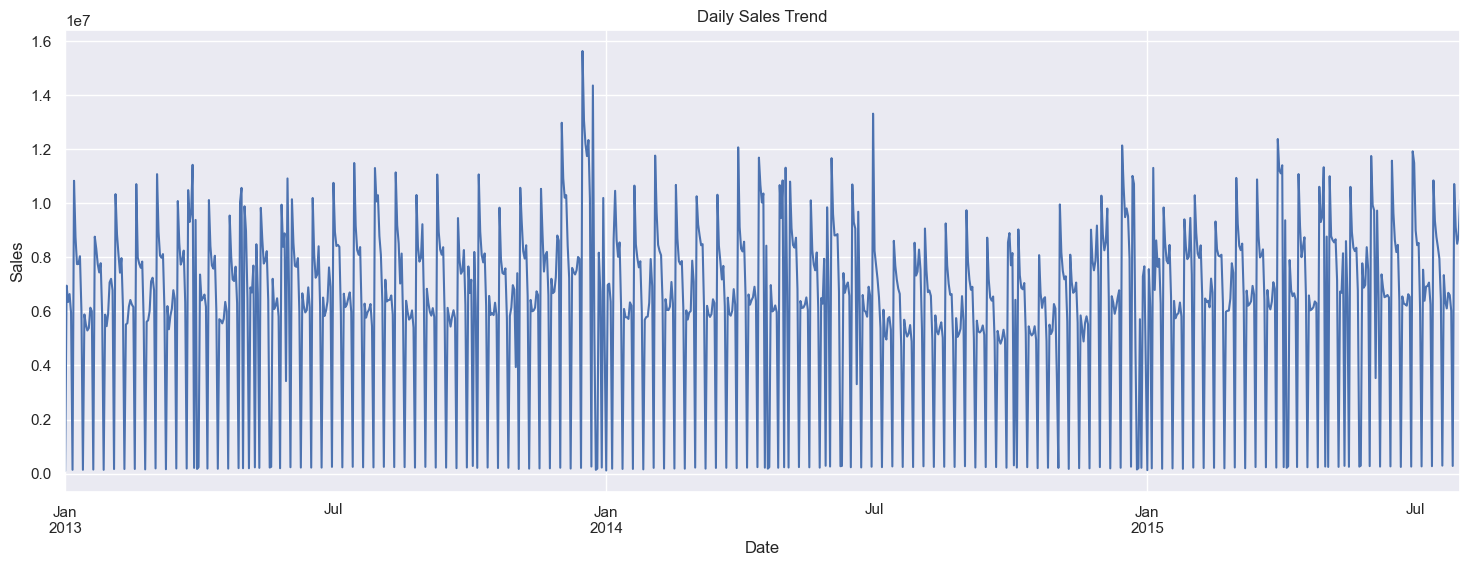

In [21]:
daily_sales = rossmann_data.groupby('Date')['Sales'].sum()

plt.figure(figsize=(18,6))
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

#### Observe:

* **Check for:**
  1. upward trend?
  2. downward trend?
  3. seasonal spikes?
  4. sudden drops?

##### **Sales show periodic fluctuations indicating strong seasonality**.

### Monthly Sales Analysis

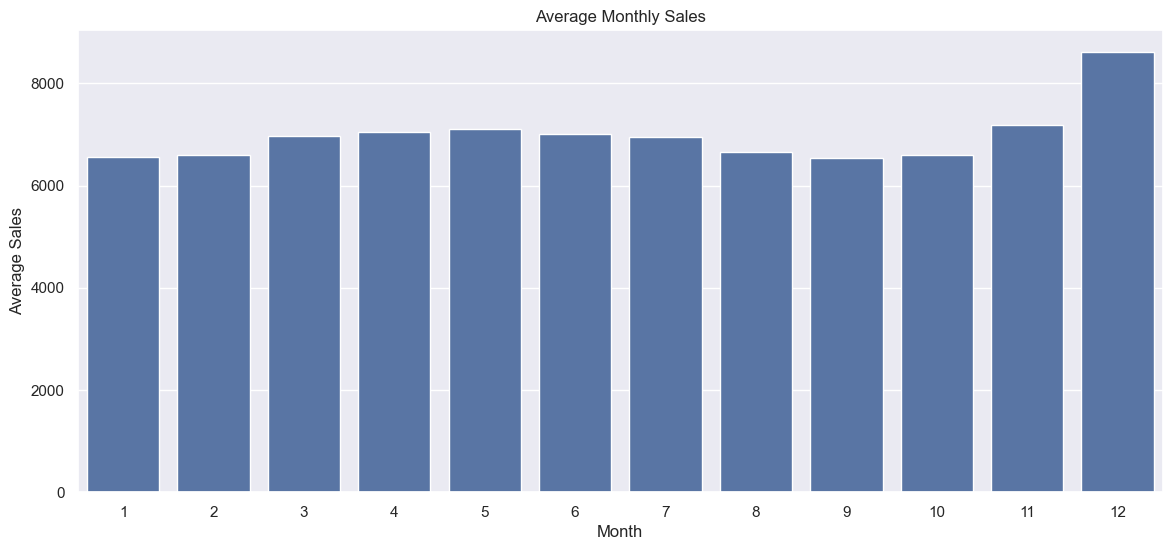

In [22]:
monthly_sales = rossmann_data.groupby('Month')['Sales'].mean()

sns.barplot(
    x = monthly_sales.index,
    y = monthly_sales.values
)

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

#### Observe

* **Look for:**
  1. Highest Month
  2. Lowest Month
  3. Seasonal Demand


**Sales Peak in December month, march - july month's sales are good compare with (jan,feb,aug,sep,oct)**

### Day of Week Sales

**This is very important for forecasting**

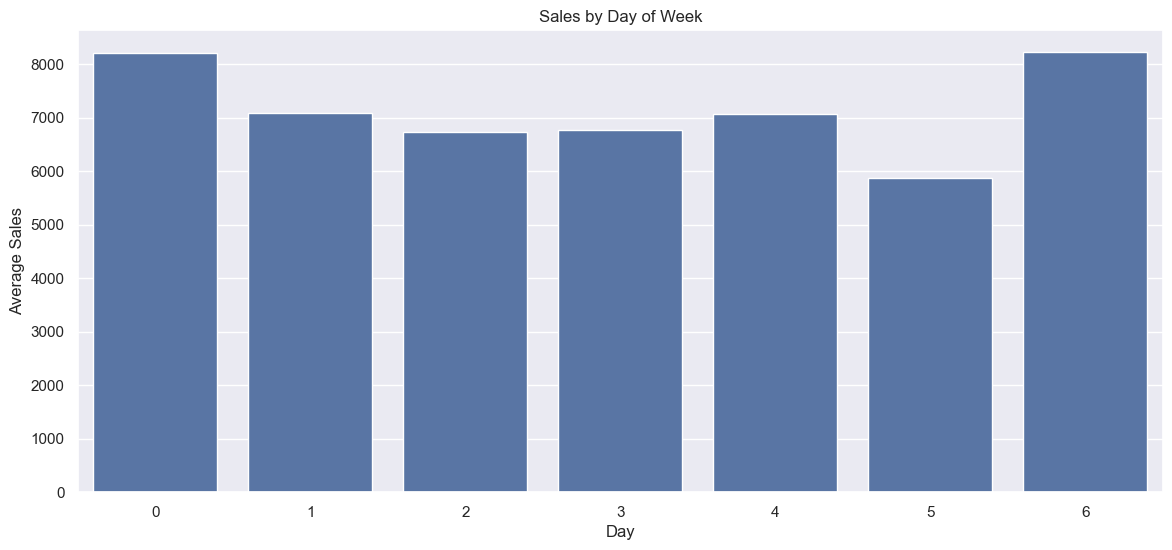

In [23]:
dow_sales = rossmann_data.groupby('DayOfWeek')['Sales'].mean()

sns.barplot(
    x = dow_sales.index,
    y = dow_sales.values
)

plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")
plt.show()

### Observe

1. **Sales are peak in Weekends**
2. **Thursday is slightly better sales compare with order weekdays** 

### Promotion Impact

**One of the strongest business signals.**


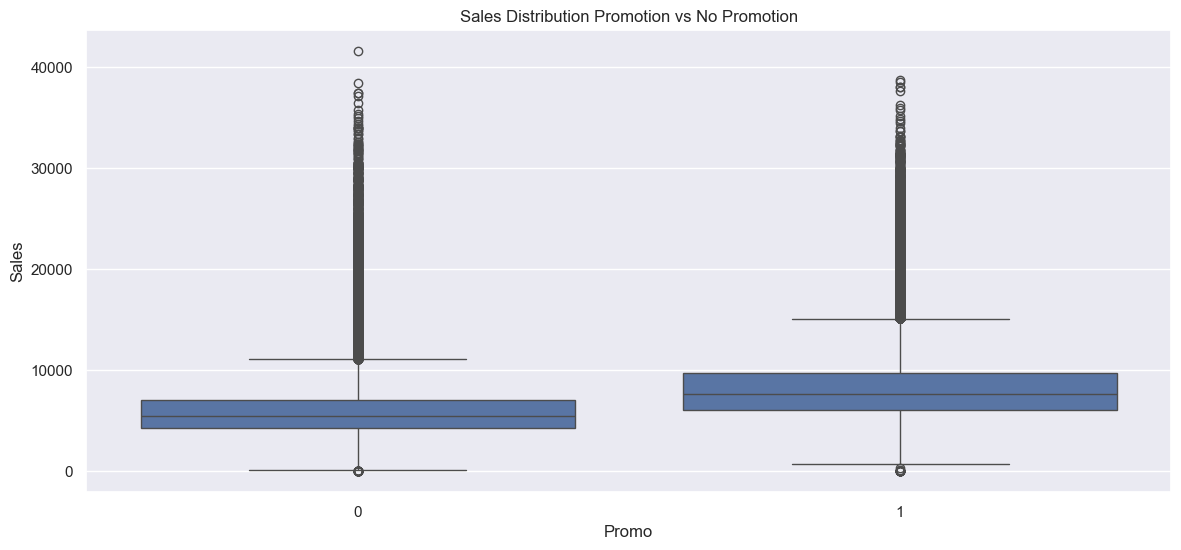

In [24]:
sns.boxplot(
    x = 'Promo',
    y = 'Sales',
    data = rossmann_data
)

plt.title("Sales Distribution Promotion vs No Promotion")
plt.show()

### Observe

**Promotions significantly improve store sales.**

### Correlation Heatmap

**Shows feature relationships.**

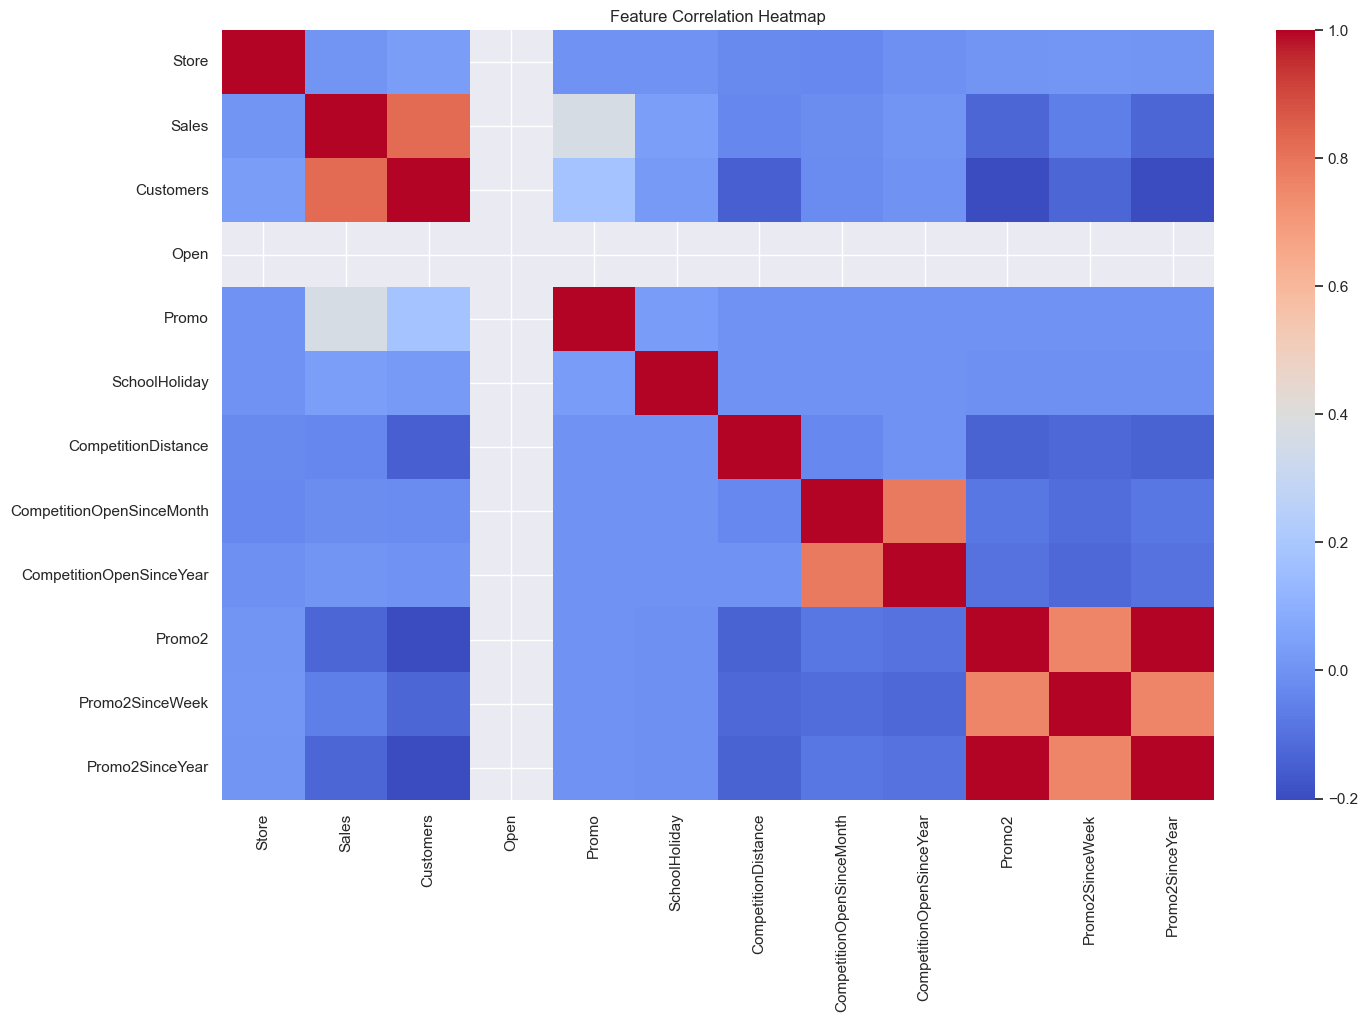

In [25]:
numeric_df = rossmann_data.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(16,10))
sns.heatmap(
    numeric_df.corr(),
    annot=False,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

### Top 10 Stores

**Business-focused analysis.**

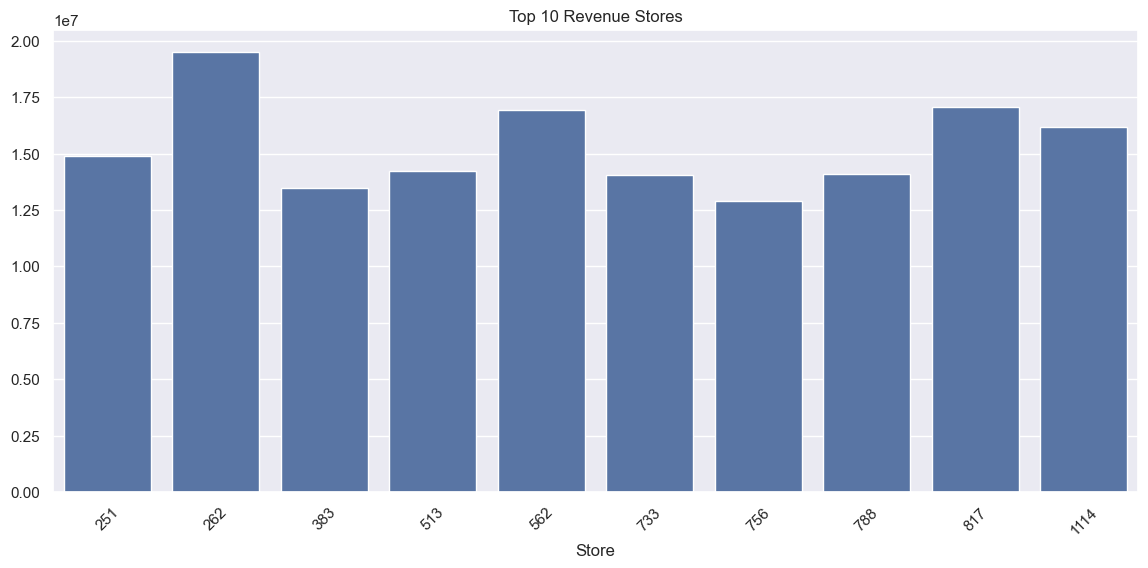

In [26]:
top_stores = rossmann_data.groupby('Store')['Sales'].sum().sort_values(ascending=False).head(10)

sns.barplot(
    x = top_stores.index,
    y = top_stores.values
)

plt.title("Top 10 Revenue Stores")
plt.xticks(rotation=45)
plt.show()

### Observe

**Rossmann's no:262 store was generating higher revenue**

### Sales Distribution

**Check skewness.**

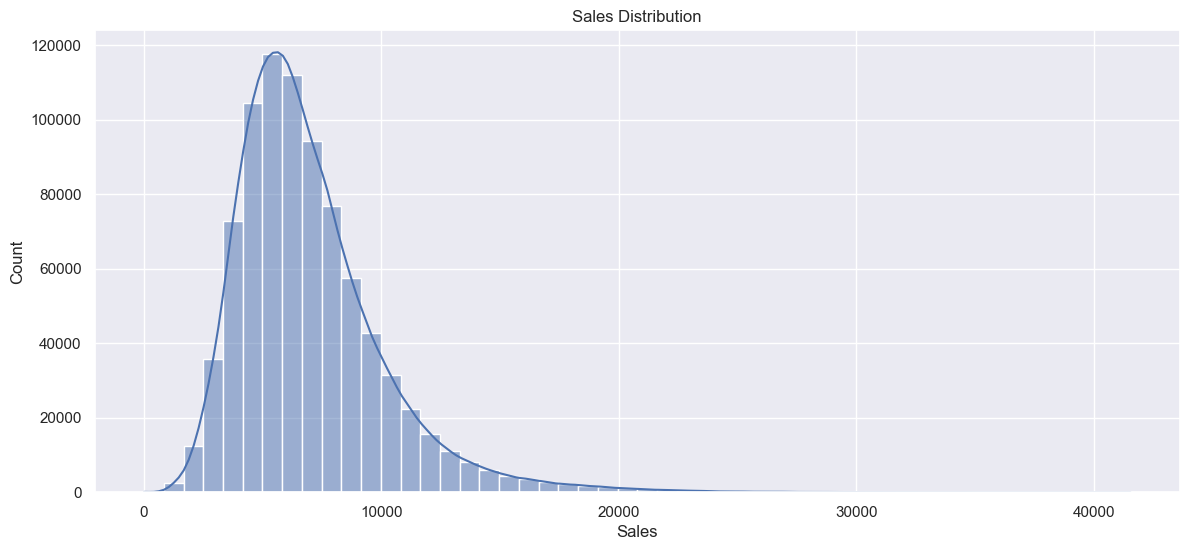

In [27]:
sns.histplot(rossmann_data['Sales'], bins=50, kde=True)
plt.title("Sales Distribution")
plt.show()

### Observation

**Retail sales are usually right-skewed.**

### Store Type Performance

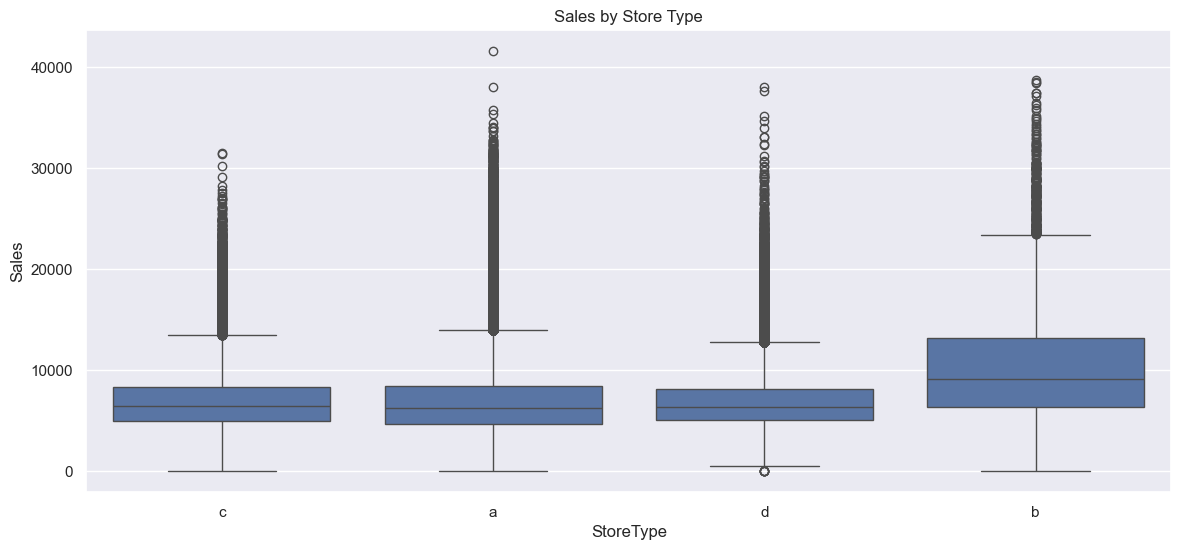

In [28]:
sns.boxplot(
    x = 'StoreType',
    y = 'Sales',
    data = rossmann_data
)

plt.title("Sales by Store Type")
plt.show()

### Holiday Effect

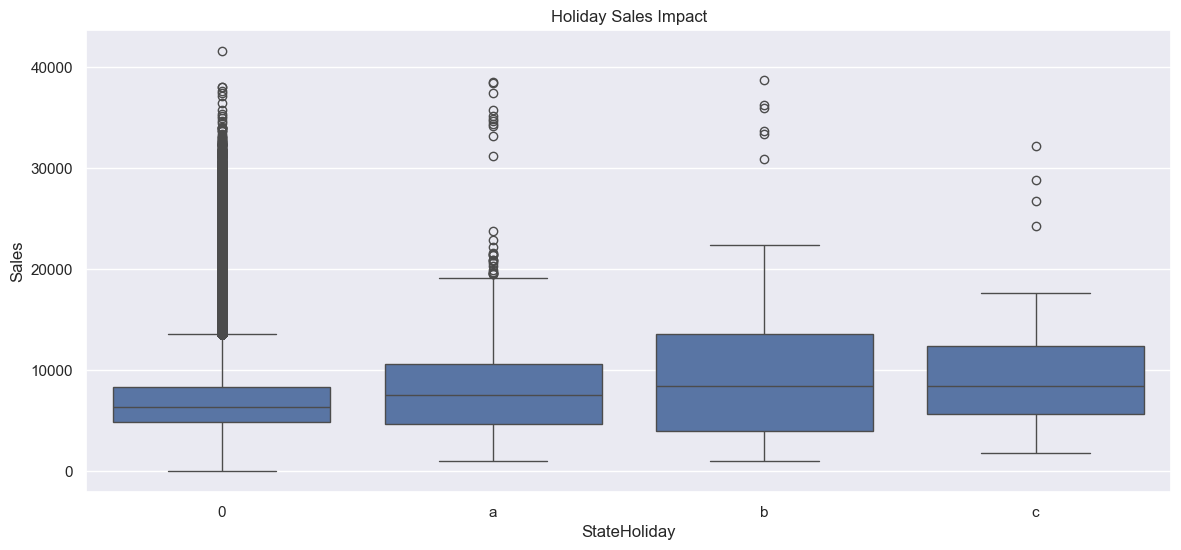

In [29]:
sns.boxplot(
    x = 'StateHoliday',
    y = 'Sales',
    data = rossmann_data
)

plt.title("Holiday Sales Impact")
plt.show()

### EDA Summary 


**Key Insights**
1. Promotions strongly increase sales
2. Sales show clear weekly/monthly seasonaliity
3. Certain store types outperform others
4. Holiday periods affect demand significantly
5. Customer count strongly correlates with sales

### Feature Engineering

In [30]:
rossmann_data = rossmann_data.sort_values(['Store','Date'])

rossmann_data['Lag_1'] = rossmann_data.groupby('Store')['Sales'].shift(1)
rossmann_data['Lag_7'] = rossmann_data.groupby('Store')['Sales'].shift(7)

rossmann_data.fillna(0, inplace=True)

# Model Building

### Define Features & Target

In [31]:
target = 'Sales'

features = [
    'Store',
    'Customers',
    'Promo',
    'SchoolHoliday',
    'DayOfWeek',
    'Month',
    'Year',
    'Day',
    'WeekOfYear',
    'Lag_1',
    'Lag_7'
]

### Create X and y

In [32]:
X = rossmann_data[features]
y = rossmann_data[target]

In [33]:
X.head()

,Store,Customers,Promo,SchoolHoliday,DayOfWeek,Month,Year,Day,WeekOfYear,Lag_1,Lag_7
1014980,1,668,0,1,2,1,2013,2,1,0.0,0.0
1013865,1,578,0,1,3,1,2013,3,1,5530.0,0.0
1012750,1,619,0,1,4,1,2013,4,1,4327.0,0.0
1011635,1,635,0,1,5,1,2013,5,1,4486.0,0.0
1009405,1,785,1,1,0,1,2013,7,2,4997.0,0.0


### Train-Test Split (Time-Series Safe)

**Since this is time-based data, don't use random split**

In [34]:
# CHRONOLOGICAL SPLIT

split_index = int(len(rossmann_data)*0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [35]:
print(X_train.shape)
print(X_test.shape)

(675513, 11)
(168879, 11)


In [36]:
print(y_train.shape)
print(y_test.shape)

(675513,)
(168879,)


### Train Random Forest

In [37]:
model = RandomForestRegressor(
    n_estimators=25,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",25
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

### Predictions

In [38]:
y_pred = model.predict(X_test)

### Evaluation Metrics

In [39]:
mae = mean_absolute_error(y_test,y_pred)
rmse = (mean_squared_error(y_test,y_pred))

print("MAE :", mae)
print("RMSE :", rmse)

MAE : 749.3085675458706
RMSE : 1209670.036365724


### Feature Importance

In [40]:
importance = pd.DataFrame({
    'Feature' : features,
    'Importance' : model.feature_importances_
}).sort_values(by='Importance',ascending=False)

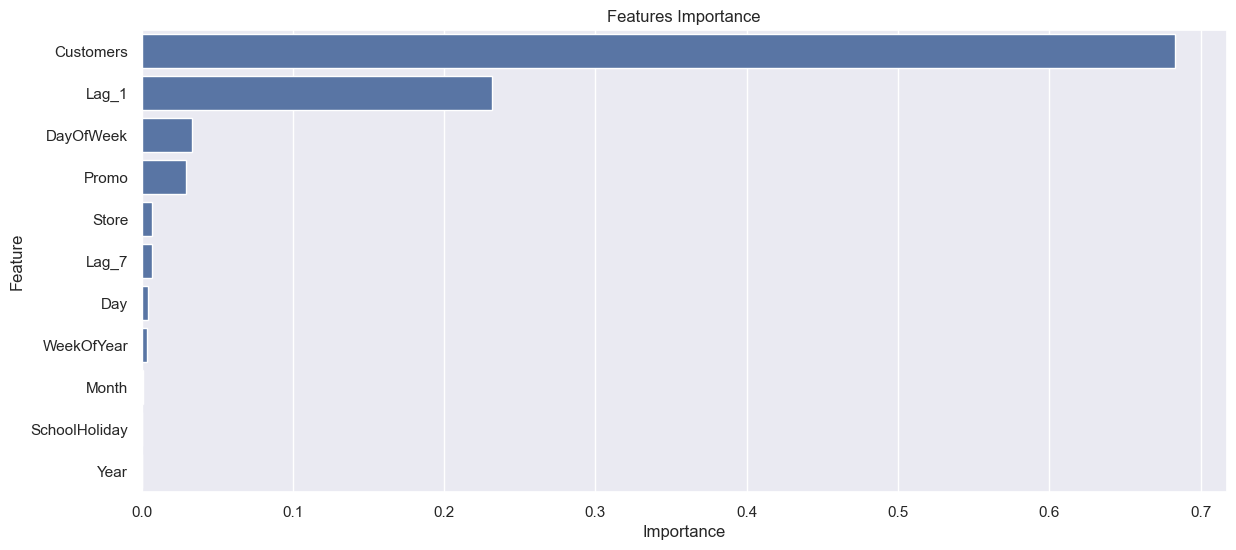

In [41]:
sns.barplot(
    x = 'Importance',
    y = 'Feature',
    data = importance
)

plt.title("Features Importance")
plt.show()

### Observe

**Usually top features:**
1. Customers
2. Lag_1
3. DayOfWeek

### Actual vs Predicted plot

**Important for showing model performance.**

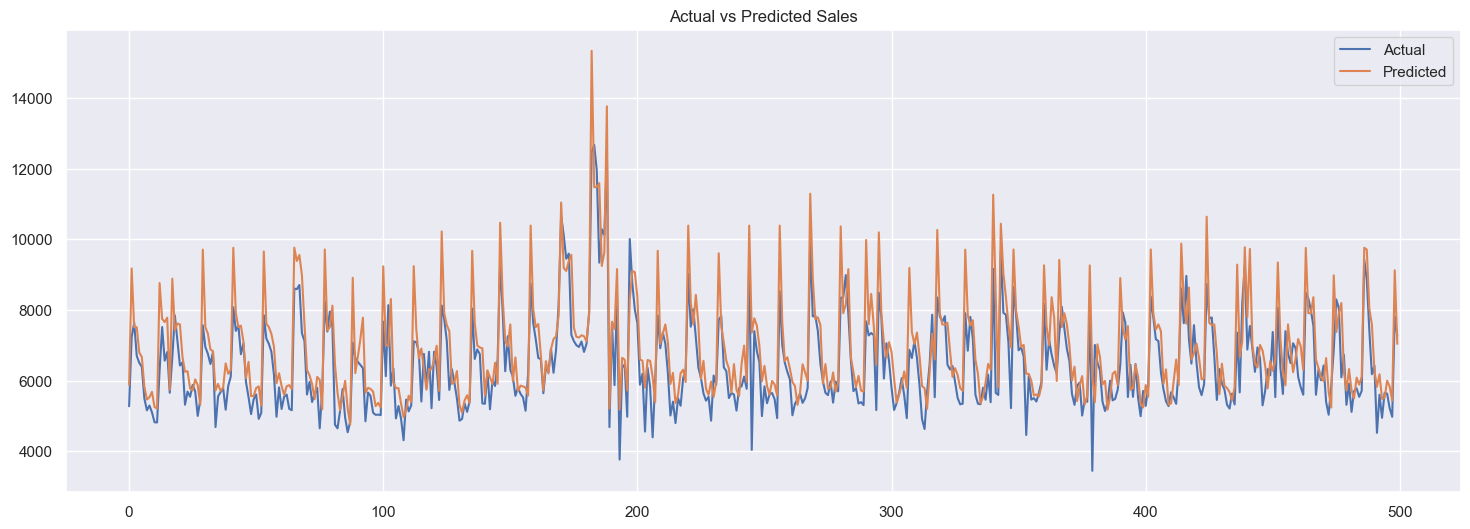

In [42]:
plt.figure(figsize=(18,6))

plt.plot(y_test.values[:500], label='Actual')
plt.plot(y_pred[:500], label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

### Inventory Recommendation logic

**This is what truns it from "ML Project" -> "Business Solution"**

In [43]:
safety_factor  = 1.2

recommended_inventory = y_pred * safety_factor

In [44]:
inventory_df = pd.DataFrame({
    'Predicted_Sales' : y_pred[:10],
    'Recommended_Stock' : recommended_inventory[:10]
})

inventory_df

,Predicted_Sales,Recommended_Stock
0,5885.273180,7062.327816
1,9178.953894,11014.744673
2,7517.784903,9021.341883
3,7517.784903,9021.341883
4,6798.716355,8158.459626
5,6676.042470,8011.250964
6,5832.666838,6999.200206
7,5468.417774,6562.101329
8,5533.163501,6639.796202
9,5686.034184,6823.241021


### Save Model (.pkl)

In [45]:
joblib.dump(model, "../models/demand_forecast_model.pkl")
joblib.dump(features, "../models/features.pkl")

['../models/features.pkl']

In [46]:
print(os.listdir("../models"))

['.ipynb_checkpoints', 'demand_forecast_model.pkl', 'features.pkl']


# Model Results

**MODEL**
1. Random Forest Regressor

**METRICS**
* MAE : 759.1419349574437
* RMSE : 1338506.7014182275

**KEY DRIVERS**
* Customers
* Promo
* Previous sales

**BUSINESS IMPACT**
1. Predicts future demand and recommends stock allocation.